In [1]:
from sklearn.datasets import fetch_california_housing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt

In [3]:
import joblib
import seaborn as sns

In [4]:
data=fetch_california_housing()

In [5]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [6]:
df=pd.DataFrame(data.data,columns=data.feature_names)

In [7]:
df['price']=data.target

In [8]:
df.sample(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
3021,3.1250,36.0,6.444444,1.111111,39.0,2.166667,35.17,-119.48,0.375
20296,4.4187,35.0,5.348337,0.998043,1814.0,3.549902,34.16,-119.19,1.834
6267,3.8409,34.0,5.459144,1.066148,977.0,3.801556,34.04,-117.94,1.630


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


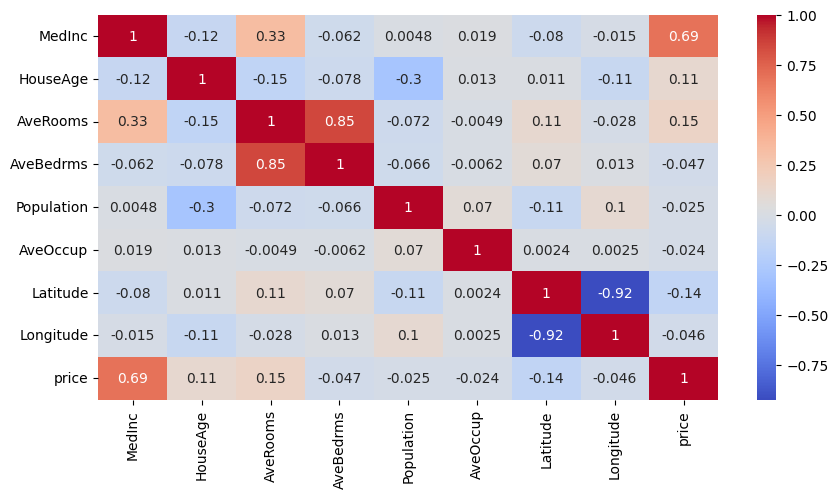

In [11]:
corr = df.corr()
plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [12]:
df.drop(columns=['Longitude','Latitude'],inplace=True)

In [13]:
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,3.521


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X=df.drop('price',axis=1)
y=df[['price']]

In [16]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
X_scaler=StandardScaler()
y_scaler=StandardScaler()


In [19]:
X_train=X_scaler.fit_transform(X_train)
y_train=y_scaler.fit_transform(y_train)

In [20]:
joblib.dump(X_scaler, "scaler_X.pkl")
joblib.dump(y_scaler, "scaler_y.pkl")

['scaler_y.pkl']

In [21]:
y_test=y_scaler.transform(y_test)
X_test=X_scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [23]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prediction
lr_pred = lr.predict(X_test)

In [24]:
# Model 2: Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Prediction
rf_pred = rf.predict(X_test)

C:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [25]:
# Linear Regression
print("Linear Regression")
print("R2 Score :", r2_score(y_test, lr_pred))
print("MAE      :", mean_absolute_error(y_test, lr_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, lr_pred)))


# Random Forest
print("\nRandom Forest")
print("R2 Score :", r2_score(y_test, rf_pred))
print("MAE      :", mean_absolute_error(y_test, rf_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, rf_pred)))

Linear Regression
R2 Score : 0.5099337366296424
MAE      : 0.5009673489711154
RMSE     : 0.693108386803009

Random Forest
R2 Score : 0.6789521386894735
MAE      : 0.3983561072000991
RMSE     : 0.5609945490260059


In [26]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

hgb.fit(X_train, y_train)

hgb_pred = hgb.predict(X_test)

print("R2 :", r2_score(y_test, hgb_pred))
print("MAE:", mean_absolute_error(y_test, hgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, hgb_pred)))

C:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


R2 : 0.6900880856361308
MAE: 0.39420542206943177
RMSE: 0.5511792851100104


In [27]:
joblib.dump(hgb,"hgb_model.pkl")

['hgb_model.pkl']

In [29]:
columns=list(X)

In [50]:
def predict():
    dic={}
    for col in columns:
        dic[col]=float(input(f"enter value of {col}:   "))
    query=pd.DataFrame([dic])
    query=X_scaler.transform(query)
    prediction=hgb.predict(query)
    pr={"price":prediction}
    pr=pd.DataFrame([pr])
    prediction=y_scaler.inverse_transform(pr)
    return f"prediction for given data is {prediction} ."

In [51]:
predict()

enter value of MedInc:    3.8409
enter value of HouseAge:    34
enter value of AveRooms:    5.459144
enter value of AveBedrms:    1.066148
enter value of Population:    977
enter value of AveOccup:    3.801


'prediction for given data is [[1.56897532]].'